# CyberTot: Parental Control AI System for Indian Families (Ages 8-14)
### End-to-End Model Training, Asymmetric Metric Evaluation & Contextual Pipeline

This notebook demonstrates:
1. **Synthetic Data Generation** tailored for Indian child digital activity (Hinglish, gaming talk, distress, grooming, scams).
2. **Core ML Classifier Training** (TF-IDF + Logistic Regression/SGDClassifier).
3. **Asymmetric Error Tuning & Metric Selection** ($F_2$ score prioritizing Recall on danger categories over Precision).
4. **Contextual Risk Aggregation** combining text classifications with metadata (time of day, sender anonymity).
5. **Selective LLM Boundary Integration** (keeping raw child data local & private while using LLM for parent daily briefings).

In [1]:
import os
import sys
# Add project root to sys.path
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
sys.path.insert(0, 'c:/Development/CyberTot')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, fbeta_score, precision_recall_fscore_support

from src.data_generator import generate_labeled_dataset, generate_daily_stream_scenario
from src.classifier import CyberTotClassifier
from src.aggregator import ContextualRiskAggregator
from src.llm_summarizer import LLMSummarizer

## 1. Synthetic Dataset Inspection
Under India's **DPDP Act**, real children's text data cannot be collected or transmitted. We generate a realistic synthetic dataset across 6 categories:

In [2]:
df = generate_labeled_dataset(samples_per_category=400)
print(f"Total Dataset Size: {len(df)} samples")
print("\nClass Distribution:")
print(df['label'].value_counts())
df.head(10)

Total Dataset Size: 2400 samples

Class Distribution:
label
safe                     492
cyberbullying            398
scam_phishing            389
grooming                 377
distress_selfharm        373
inappropriate_content    371
Name: count, dtype: int64


,text,label
0,watch free 18+ adult movies HD online number,inappropriate_content
1,"sone ka mann nahi karta alone, bas akele rehne...",distress_selfharm
2,"hey cutie, send group of u, keep this a secret...",grooming
3,"kuch accha nahi lag raha link, har waqt rona a...",distress_selfharm
4,how to bypass parental control pin on android ...,inappropriate_content
5,bhai photo bhej de class notes ki alone pe please,safe
6,FREE ROBUX - enter parents credit card details...,scam_phishing
7,"I feel so empty and tired of photo, want to di...",distress_selfharm
8,Congratulations! You won free iPhone enter OTP...,scam_phishing
9,are u alone at home? camera on karke photo cal...,grooming


## 2. Model Training & Headline Macro F2 Evaluation
We train our lightweight local classifier and evaluate it across risk categories:

In [3]:
train_size = int(0.8 * len(df))
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

model = CyberTotClassifier()
model.fit(train_df['text'], train_df['label'])
results = model.evaluate(test_df['text'], test_df['label'])

Model trained successfully on 1920 samples across classes: ['cyberbullying', 'distress_selfharm', 'grooming', 'inappropriate_content', 'safe', 'scam_phishing']

PROBABILITY THRESHOLD SWEEP DEMONSTRATION (GROOMING & DISTRESS CLASS)
Threshold T  | Grooming Recall  | Grooming Precision | Macro F2 Score
-------------------------------------------------------------------------------------
0.10         |           100.0% |              89.5% |        0.9187
0.15         |           100.0% |              89.5% |        0.9331  <--- (TUNED OPERATING POINT)
0.25         |           100.0% |              89.5% |        0.9331


0.40         |           100.0% |              89.5% |        0.9331
0.60         |           100.0% |              89.5% |        0.9331
0.80         |            49.4% |              92.7% |        0.6468
0.90         |             0.0% |               0.0% |        0.0904

--- Classification Report (Tuned Operating Point T=0.15) ---
                       precision    recall  f1-score   support

        cyberbullying       0.94      0.96      0.95        83
    distress_selfharm       0.87      1.00      0.93        72
             grooming       0.90      1.00      0.94        77
inappropriate_content       0.93      1.00      0.97        83
                 safe       0.95      0.66      0.78        92
        scam_phishing       1.00      1.00      1.00        73

             accuracy                           0.93       480
            macro avg       0.93      0.94      0.93       480
         weighted avg       0.93      0.93      0.92       480



## 3. Probability Threshold Sweep Curve (Grooming & Distress)
We analyze the effect of moving the decision threshold $T$ from $0.10$ to $0.90$:

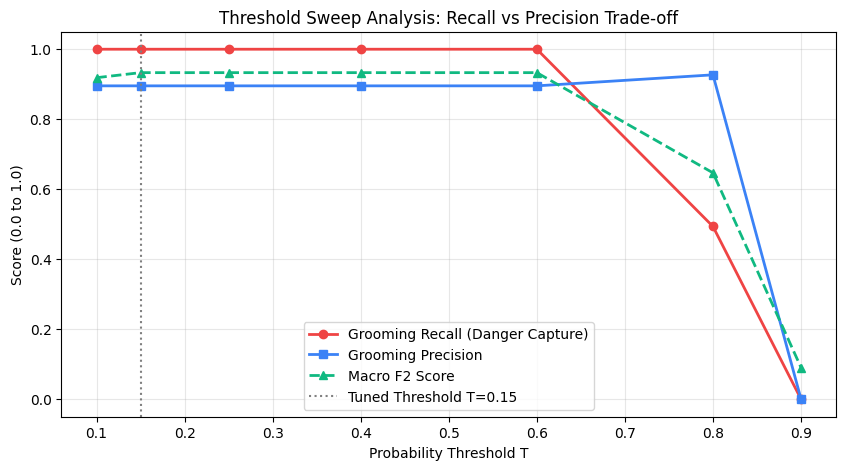

In [4]:
thresholds = [0.10, 0.15, 0.25, 0.40, 0.60, 0.80, 0.90]
recalls = []
precisions = []
f2_scores = []

grooming_idx = model.classes_.index("grooming")

for t in thresholds:
    t_map = {cls: t for cls in model.classes_ if cls != "safe"}
    t_map["safe"] = 0.50
    y_pred = model.predict(test_df['text'], custom_thresholds=t_map)
    p, r, _, _ = precision_recall_fscore_support(test_df['label'], y_pred, labels=model.classes_, beta=2, zero_division=0)
    macro_f2 = fbeta_score(test_df['label'], y_pred, beta=2, average='macro', zero_division=0)
    
    recalls.append(r[grooming_idx])
    precisions.append(p[grooming_idx])
    f2_scores.append(macro_f2)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, recalls, marker='o', label='Grooming Recall (Danger Capture)', color='#ef4444', linewidth=2)
plt.plot(thresholds, precisions, marker='s', label='Grooming Precision', color='#3b82f6', linewidth=2)
plt.plot(thresholds, f2_scores, marker='^', label='Macro F2 Score', color='#10b981', linewidth=2, linestyle='--')
plt.axvline(x=0.15, color='gray', linestyle=':', label='Tuned Threshold T=0.15')
plt.title('Threshold Sweep Analysis: Recall vs Precision Trade-off')
plt.xlabel('Probability Threshold T')
plt.ylabel('Score (0.0 to 1.0)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Confusion Matrix Visualization

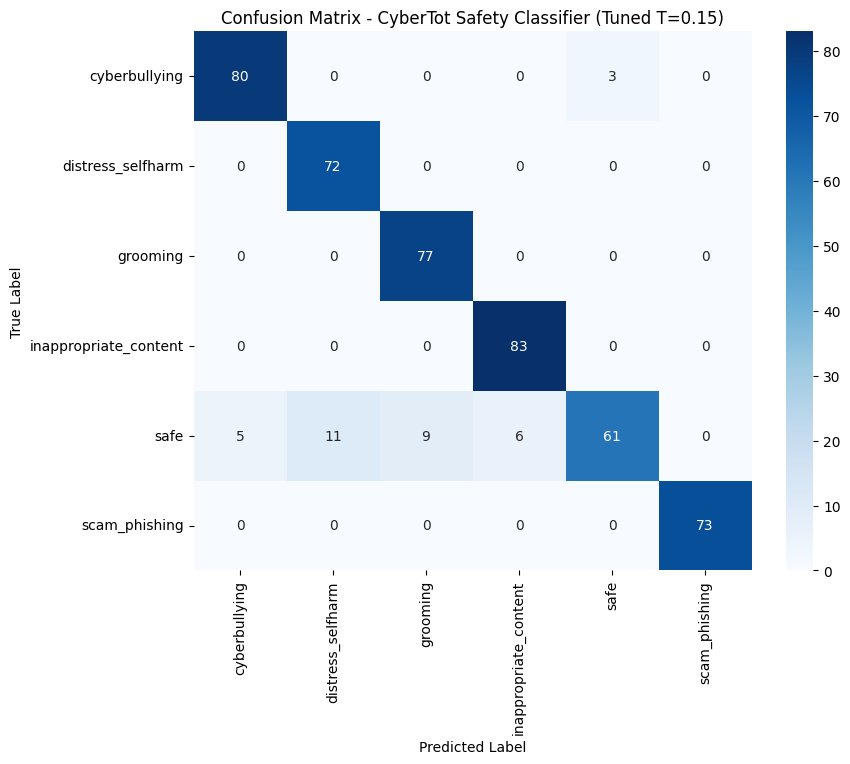

In [5]:
y_test = test_df['label']
y_pred = model.predict(test_df['text'])

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix - CyberTot Safety Classifier (Tuned T=0.15)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 5. End-to-End Stream Simulation & Contextual Aggregation

In [6]:
stream_events = generate_daily_stream_scenario('grooming_attempt')
aggregator = ContextualRiskAggregator(classifier=model)
stream_analysis = aggregator.analyze_stream(stream_events)

print("=== REAL-TIME SAFETY STATUS ===")
print(f"Status: {stream_analysis['realtime_status']['status']}")
print(f"Headline: {stream_analysis['realtime_status']['headline']}")
print(f"Max Risk Score: {stream_analysis['realtime_status']['max_risk_score']} / 100")
print(f"Flagged Events: {stream_analysis['today_summary']['flagged_events_count']}")

=== REAL-TIME SAFETY STATUS ===
Status: DANGER
Headline: Action Required: Potential Severe Risk Detected
Max Risk Score: 100.0 / 100
Flagged Events: 3


## 6. Selective LLM Parent Briefing Generation

In [7]:
summarizer = LLMSummarizer()
parent_briefing = summarizer.generate_daily_parent_briefing(stream_analysis)
print(parent_briefing)

No GEMINI_API_KEY found. Running with deterministic rule-based LLM fallback generator.
### Safety Status: High Attention Required

**Is My Child Safe Right Now?**
No, urgent attention is recommended. A high-priority risk alert was detected today involving suspicious communications from an unknown account during late-night hours. We advise calmly talking with your child without scolding them.

**What Happened Today?**
* **Digital Activity:** Main screen time was recorded on Whatsapp (5.0 min), Youtube (40.0 min), Client (80.3 min).
* **Flagged Safety Alerts:** 3 event(s) were flagged by the local security model.
* **Key Concern:** Contact from an unrecognized user asking for social media handles and requesting secrecy.
* **Parental Action Tip:** Remind your child that they can always share online conversations with you without fear of losing their device privileges.
